In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


TEST KODE 1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

MENCARI JUMLAH CLUSTER (K) OPTIMAL DENGAN ELBOW & SILHOUETTE
--> K = 2 | WCSS = 885.08 | Silhouette = 0.6137
--> K = 3 | WCSS = 462.32 | Silhouette = 0.5120
--> K = 4 | WCSS = 284.19 | Silhouette = 0.5032
--> K = 5 | WCSS = 204.23 | Silhouette = 0.4696
--> K = 6 | WCSS = 164.21 | Silhouette = 0.4344
--> K = 7 | WCSS = 139.88 | Silhouette = 0.4010
--> K = 8 | WCSS = 119.32 | Silhouette = 0.3988
--> K = 9 | WCSS = 107.67 | Silhouette = 0.3851
--> K = 10 | WCSS = 102.48 | Silhouette = 0.3842


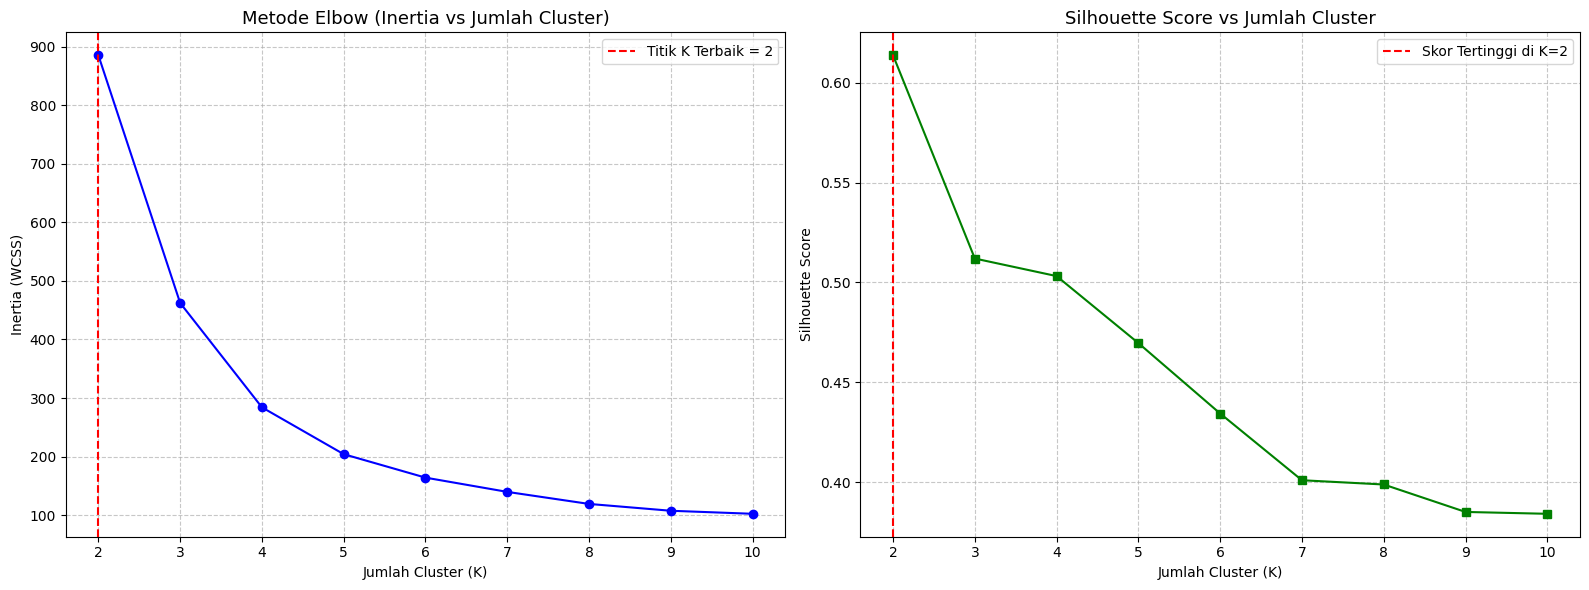

K-Means Dasar
Incremental K-Means


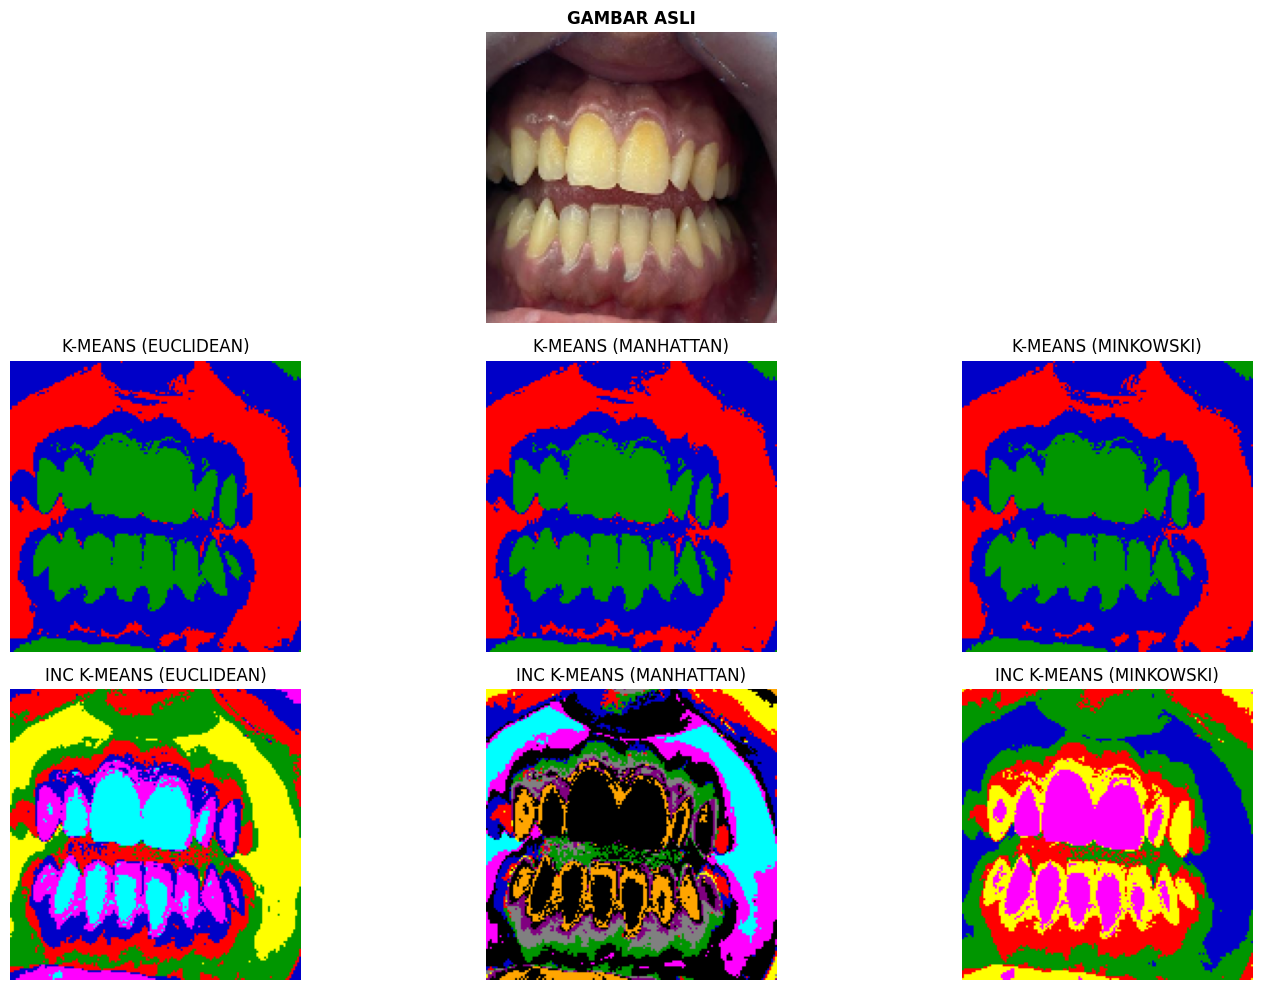


                GRAFIK HASIL EVALUASI


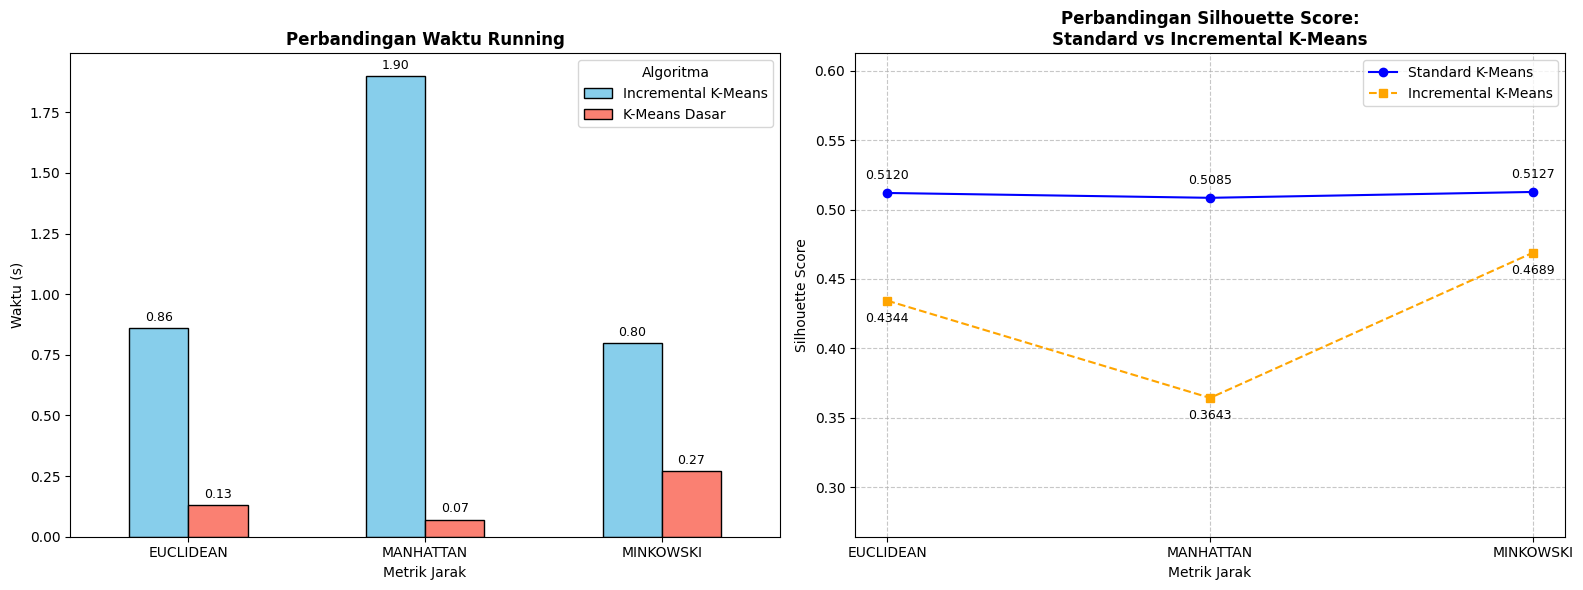

In [ ]:
# Tambahan modul untuk Google Colab agar bisa baca dataset di Drive
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import silhouette_score

# RUMUS JARAK
def jarak_euclidean(X, centroids, **kwargs):
    selisih = X[:, np.newaxis] - centroids
    return np.sqrt(np.sum(selisih**2, axis=2))

def jarak_manhattan(X, centroids, **kwargs):
    selisih = X[:, np.newaxis] - centroids
    return np.sum(np.abs(selisih), axis=2)

def jarak_minkowski(X, centroids, p=3, **kwargs):
    selisih = X[:, np.newaxis] - centroids
    return np.sum(np.abs(selisih)**p, axis=2)**(1/p)

def jarak_titik_euclidean(titik, centroids, **kwargs):
    return np.sqrt(np.sum((titik - centroids)**2, axis=1))

def jarak_titik_manhattan(titik, centroids, **kwargs):
    return np.sum(np.abs(titik - centroids), axis=1)

def jarak_titik_minkowski(titik, centroids, p=3, **kwargs):
    return np.sum(np.abs(titik - centroids)**p, axis=1)**(1/p)

# ALGORITMA K-MEANS
def kmeans_dasar(X, k, centroid_awal, fungsi_jarak, nilai_p=3, max_iter=100, toleransi=1e-4):
    centroids = centroid_awal.copy()
    for iterasi in range(max_iter):
        distances = fungsi_jarak(X, centroids, p=nilai_p)
        labels = np.argmin(distances, axis=1)
        old_centroids = centroids.copy()

        new_centroids = []
        for i in range(k):
            points = X[labels == i]
            if len(points) > 0:
                new_centroids.append(np.mean(points, axis=0))
            else:
                new_centroids.append(centroids[i])

        centroids = np.array(new_centroids)
        if np.allclose(old_centroids, centroids, atol=toleransi):
            break
    return centroids, labels

def incremental_kmeans(X, threshold_T, fungsi_jarak_titik, fungsi_jarak_semua, nilai_p=3, max_iter=100, toleransi=1e-4):
    centroids_list = [X[0]]
    labels = np.zeros(len(X), dtype=int)

    for i in range(1, len(X)):
        titik = X[i]
        jarak_ke_centroids = fungsi_jarak_titik(titik, np.array(centroids_list), p=nilai_p)
        jarak_minimum = np.min(jarak_ke_centroids)

        if jarak_minimum > threshold_T:
            centroids_list.append(titik)
            labels[i] = len(centroids_list) - 1
        else:
            labels[i] = np.argmin(jarak_ke_centroids)

    centroids = np.array(centroids_list)
    k_terbentuk = len(centroids)

    for iterasi in range(max_iter):
        distances = fungsi_jarak_semua(X, centroids, p=nilai_p)
        labels = np.argmin(distances, axis=1)
        old_centroids = centroids.copy()

        new_centroids = []
        for c in range(k_terbentuk):
            points = X[labels == c]
            if len(points) > 0:
                new_centroids.append(np.mean(points, axis=0))
            else:
                new_centroids.append(centroids[c])

        centroids = np.array(new_centroids)
        if np.allclose(old_centroids, centroids, atol=toleransi):
            break
    return centroids, labels

# FUNGSI MENCARI K OPTIMAL (ELBOW & SILHOUETTE)
def cari_k_optimal(path_gambar, max_k=10):
    print("\n" + "="*60)
    print("MENCARI JUMLAH CLUSTER (K) OPTIMAL DENGAN ELBOW & SILHOUETTE")
    print("="*60)

    image = cv2.imread(path_gambar)
    if image is None:
        print(f"Gambar gagal dimuat dari: {path_gambar}")
        return

    image_kecil = cv2.resize(image, (150, 150))
    image_warna = cv2.cvtColor(image_kecil, cv2.COLOR_BGR2RGB)
    X = image_warna.reshape((-1, 3)) / 255.0

    wcss_list = []
    sil_list = []
    k_range = list(range(2, max_k + 1))

    for k in k_range:
        np.random.seed(42)
        centroid_awal = X[np.random.choice(len(X), k, replace=False)]

        centroids_akhir, labels_akhir = kmeans_dasar(X, k, centroid_awal, fungsi_jarak=jarak_euclidean)

        # Hitung WCSS (Elbow)
        wcss = np.sum((X - centroids_akhir[labels_akhir])**2)
        wcss_list.append(wcss)

        # Hitung Silhouette Score
        jumlah_unik = len(np.unique(labels_akhir))
        if 1 < jumlah_unik < len(X):
            skor = silhouette_score(X, labels_akhir, sample_size=5000, random_state=42)
        else:
            skor = 0

        sil_list.append(skor)
        print(f"--> K = {k} | WCSS = {wcss:.2f} | Silhouette = {skor:.4f}")

    k_terbaik = k_range[np.argmax(sil_list)]

    # Plot Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Grafik 1: Elbow Method
    axes[0].plot(k_range, wcss_list, marker='o', color='blue', linestyle='-')
    axes[0].set_title('Metode Elbow (Inertia vs Jumlah Cluster)', fontsize=13)
    axes[0].set_xlabel('Jumlah Cluster (K)')
    axes[0].set_ylabel('Inertia (WCSS)')
    axes[0].axvline(x=k_terbaik, color='red', linestyle='--', label=f'Titik K Terbaik = {k_terbaik}')
    axes[0].set_xticks(k_range)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend()

    # Grafik 2: Silhouette Score
    axes[1].plot(k_range, sil_list, marker='s', color='green', linestyle='-')
    axes[1].set_title('Silhouette Score vs Jumlah Cluster', fontsize=13)
    axes[1].set_xlabel('Jumlah Cluster (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].axvline(x=k_terbaik, color='red', linestyle='--', label=f'Skor Tertinggi di K={k_terbaik}')
    axes[1].set_xticks(k_range)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# FUNGSI PENGUJIAN & VISUALISASI GRID TERPADU
def uji_semua_skenario(path_gambar, palet_warna, k=3, threshold_T=0.3):
    image = cv2.imread(path_gambar)
    if image is None: return

    image_kecil = cv2.resize(image, (150, 150))
    image_warna = cv2.cvtColor(image_kecil, cv2.COLOR_BGR2RGB)
    tinggi, lebar, channel = image_warna.shape
    X = image_warna.reshape((-1, 3)) / 255.0

    data_evaluasi = []

    plt.figure(figsize=(15, 10))
    plt.subplot(3, 3, 2)
    plt.imshow(image_warna)
    plt.title('GAMBAR ASLI', fontweight='bold')
    plt.axis('off')

    skenario_kmeans = [('EUCLIDEAN', jarak_euclidean), ('MANHATTAN', jarak_manhattan), ('MINKOWSKI', jarak_minkowski)]
    skenario_inc_kmeans = [('EUCLIDEAN', jarak_euclidean, jarak_titik_euclidean), ('MANHATTAN', jarak_manhattan, jarak_titik_manhattan), ('MINKOWSKI', jarak_minkowski, jarak_titik_minkowski)]

    print("K-Means Dasar")
    np.random.seed(42)
    centroid_awal = X[np.random.choice(len(X), k, replace=False)]

    for i, (nama_jarak, fungsi_jarak) in enumerate(skenario_kmeans):
        waktu_mulai = time.process_time()
        centroids_akhir, labels_akhir = kmeans_dasar(X, k, centroid_awal, fungsi_jarak=fungsi_jarak)
        total_waktu = round(time.process_time() - waktu_mulai, 4)
        jumlah_cluster = len(np.unique(labels_akhir))
        skor_siluet = silhouette_score(X, labels_akhir, sample_size=5000, random_state=42) if 1 < jumlah_cluster < len(X) else 0

        data_evaluasi.append({'Algoritma': 'K-Means Dasar', 'Metrik Jarak': nama_jarak, 'Waktu Running (s)': total_waktu, 'Silhouette Score': skor_siluet})

        warna_array = np.array(palet_warna, dtype=np.uint8)
        if len(warna_array) < jumlah_cluster:
            warna_array = np.vstack((warna_array, np.zeros((jumlah_cluster - len(warna_array), 3), dtype=np.uint8)))

        plt.subplot(3, 3, i + 4)
        plt.imshow(warna_array[labels_akhir].reshape((tinggi, lebar, channel)))
        plt.title(f'K-MEANS ({nama_jarak})')
        plt.axis('off')

    print("Incremental K-Means")
    for i, (nama_jarak, f_jarak_semua, f_jarak_titik) in enumerate(skenario_inc_kmeans):
        waktu_mulai = time.process_time()
        centroids_akhir, labels_akhir = incremental_kmeans(X, threshold_T, fungsi_jarak_titik=f_jarak_titik, fungsi_jarak_semua=f_jarak_semua)
        total_waktu = round(time.process_time() - waktu_mulai, 4)
        jumlah_cluster = len(np.unique(labels_akhir))
        skor_siluet = silhouette_score(X, labels_akhir, sample_size=5000, random_state=42) if 1 < jumlah_cluster < len(X) else 0

        data_evaluasi.append({'Algoritma': 'Incremental K-Means', 'Metrik Jarak': nama_jarak, 'Waktu Running (s)': total_waktu, 'Silhouette Score': skor_siluet})

        warna_array = np.array(palet_warna, dtype=np.uint8)
        if len(warna_array) < jumlah_cluster:
            warna_array = np.vstack((warna_array, np.zeros((jumlah_cluster - len(warna_array), 3), dtype=np.uint8)))

        plt.subplot(3, 3, i + 7)
        plt.imshow(warna_array[labels_akhir].reshape((tinggi, lebar, channel)))
        plt.title(f'INC K-MEANS ({nama_jarak})')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # GRAFIK HASIL EVALUASI (WAKTU & SILHOUETTE)
    print("\n" + "="*60)
    print("                GRAFIK HASIL EVALUASI")
    print("="*60)

    df_evaluasi = pd.DataFrame(data_evaluasi)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    urutan_metrik = ['EUCLIDEAN', 'MANHATTAN', 'MINKOWSKI']

    # Grafik Waktu Running
    df_waktu = df_evaluasi.pivot(index='Metrik Jarak', columns='Algoritma', values='Waktu Running (s)').reindex(urutan_metrik)
    df_waktu.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'], edgecolor='black')
    axes[0].set_title('Perbandingan Waktu Running', fontweight='bold')
    axes[0].set_ylabel('Waktu (s)')
    axes[0].set_xlabel('Metrik Jarak')
    axes[0].tick_params(axis='x', rotation=0)

    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

    # Grafik Silhouette Score
    std_sil = df_evaluasi[df_evaluasi['Algoritma'] == 'K-Means Dasar'].set_index('Metrik Jarak').reindex(urutan_metrik)['Silhouette Score'].values
    inc_sil = df_evaluasi[df_evaluasi['Algoritma'] == 'Incremental K-Means'].set_index('Metrik Jarak').reindex(urutan_metrik)['Silhouette Score'].values

    axes[1].plot(urutan_metrik, std_sil, marker='o', color='blue', linestyle='-', label='Standard K-Means')
    axes[1].plot(urutan_metrik, inc_sil, marker='s', color='orange', linestyle='--', label='Incremental K-Means')

    axes[1].set_title('Perbandingan Silhouette Score:\nStandard vs Incremental K-Means', fontweight='bold')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_xlabel('Metrik Jarak')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend()

    for i in range(len(urutan_metrik)):
        axes[1].annotate(f"{std_sil[i]:.4f}", (i, std_sil[i]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
        axes[1].annotate(f"{inc_sil[i]:.4f}", (i, inc_sil[i]), textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9)

    batas_atas = max(max(std_sil), max(inc_sil)) + 0.1
    batas_bawah = min(min(std_sil), min(inc_sil)) - 0.1
    axes[1].set_ylim(batas_bawah, batas_atas)

    plt.tight_layout()
    plt.show()

# EKSEKUSI UTAMA
PATH_GAMBAR_UJI = "/content/drive/MyDrive/dental-plaque.v1i.coco-segmentation/train/0000_jpeg_jpg.rf.3d5dffe555c115523427df64485a268b.jpg"

PALET_WARNA = [
    [255, 0, 0],    # Cluster 1: Merah
    [0, 150, 0],    # Cluster 2: Hijau Gelap
    [0, 0, 200],    # Cluster 3: Biru Gelap
    [255, 255, 0],  # Cluster 4: Kuning
    [255, 0, 255],  # Cluster 5: Magenta
    [0, 255, 255],  # Cluster 6: Cyan
    [255, 165, 0],  # Cluster 7: Orange
    [128, 0, 128],  # Cluster 8: Ungu
    [128, 128, 128],# Cluster 9: Abu-abu
    [0, 0, 0]       # Cluster 10: Hitam
]

# Menghitung metode Elbow dan Silhouette
cari_k_optimal(PATH_GAMBAR_UJI, max_k=10)

# Tes perbandingan algoritma
uji_semua_skenario(PATH_GAMBAR_UJI, PALET_WARNA, k=3, threshold_T=0.3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print ("hello wolrd")

hello wolrd
